In [1]:
# script to really quickly give the ignition delay at T = 830K and P = 10atm and phi = 1.0

In [161]:
import os
import copy
import cantera as ct
import numpy as np
import pandas as pd
import concurrent.futures
import rmgpy.chemkin
import rmgpy.quantity

import sys
sys.path.append(os.path.join(os.environ['AUTOSCIENCE_REPO'], 'analysis'))

import ignition_delay

import os
import re
import glob
import yaml
import time

import rmgpy.chemkin
import rmgpy.data.kinetics
import rmgpy.data.thermo
import rmgpy.data.rmg
import rmgpy.solver.simple

import numpy as np
import pandas as pd
# import importlib
# importlib.reload(rmgpy.data.kinetics)

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

import sys
sys.path.append('/work/westgroup/harris.se/autoscience/reaction_calculator/database/')
import database_fun
import subprocess

import matplotlib.pyplot as plt
%matplotlib inline

DFT_DIR = os.environ['DFT_DIR']

In [172]:
chemkin = '/work/westgroup/harris.se/autoscience/fuels/butane/RMG_min/butane_20241219/chem_annotated.inp'
# chemkin = '/work/westgroup/harris.se/autoscience/fuels/butane/RMG_MAX/butane_20241219/chem_annotated.inp'

In [173]:
sp_dict = os.path.join(os.path.dirname(chemkin), 'species_dictionary.txt')
species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, sp_dict)
base_species_list, base_reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, sp_dict)

In [174]:
DELTA_J_MOL = 418.4  # J/mol, but equals 0.1 kcal/mol
R = 8.3144598  # gas constant in J/mol
DELTA = 0.01
# perturb every species and reaction in the mechanism
# we'll select the perturbations one at a time later in the script
def perturb_species(species):  # TODO maybe load this from a util Python module so code doesn't get repeated so much
    # takes in an RMG species object
    # change the enthalpy offset
    increase = None
    for poly in species.thermo.polynomials:
        new_coeffs = poly.coeffs
        if not increase:
            # Only define the increase in enthalpy once or you'll end up with numerical gaps in continuity
            # increase = DELTA * new_coeffs[5]
            increase = DELTA_J_MOL / R
        new_coeffs[5] += increase
        poly.coeffs = new_coeffs


def perturb_reaction(rxn):
    # takes in an RMG reaction object
    # delta is the ln(k) amount to perturb the A factor
    # delta is a multiplicative factor- units don't matter, yay!
    # does not deepycopy because there's some issues with rmgpy.reactions copying
    if type(rxn.kinetics) == rmgpy.kinetics.chebyshev.Chebyshev:
        rxn.kinetics.coeffs.value_si[0][0] += np.log10(1.0 + DELTA)
    elif type(rxn.kinetics) in [rmgpy.kinetics.falloff.Troe, rmgpy.kinetics.falloff.ThirdBody, rmgpy.kinetics.falloff.Lindemann]:
        if hasattr(rxn.kinetics, 'arrheniusHigh'):
            rxn.kinetics.arrheniusHigh.A.value *= np.exp(DELTA)
        if hasattr(rxn.kinetics, 'arrheniusLow'):
            rxn.kinetics.arrheniusLow.A.value *= np.exp(DELTA)
    elif type(rxn.kinetics) == rmgpy.kinetics.arrhenius.MultiArrhenius:
        for j in range(len(rxn.kinetics.arrhenius)):
            rxn.kinetics.arrhenius[j].A.value *= np.exp(DELTA)
    elif type(rxn.kinetics) == rmgpy.kinetics.arrhenius.PDepArrhenius:
        for j in range(len(rxn.kinetics.arrhenius)):
            if type(rxn.kinetics.arrhenius[j]) == rmgpy.kinetics.arrhenius.Arrhenius:
                rxn.kinetics.arrhenius[j].A.value *= np.exp(DELTA)
            elif type(rxn.kinetics.arrhenius[j]) == rmgpy.kinetics.arrhenius.MultiArrhenius:
                for k in range(len(rxn.kinetics.arrhenius[j].arrhenius)):
                    rxn.kinetics.arrhenius[j].arrhenius[k].A.value *= np.exp(DELTA)
            else:
                raise ValueError(f'weird kinetics {str(rxn.kinetics)}')
    elif type(rxn.kinetics) == rmgpy.kinetics.arrhenius.MultiPDepArrhenius:
        for i in range(len(rxn.kinetics.arrhenius)):
            for j in range(len(rxn.kinetics.arrhenius[i].arrhenius)):
                if type(rxn.kinetics.arrhenius[i].arrhenius[j]) == rmgpy.kinetics.arrhenius.Arrhenius:
                    rxn.kinetics.arrhenius[i].arrhenius[j].A.value *= np.exp(DELTA)
                elif type(rxn.kinetics.arrhenius[i].arrhenius[j]) == rmgpy.kinetics.arrhenius.MultiArrhenius:
                    for k in range(len(rxn.kinetics.arrhenius[i].arrhenius[j].arrhenius)):
                        rxn.kinetics.arrhenius[i].arrhenius[j].arrhenius[k].A.value *= np.exp(DELTA)
                else:
                    raise ValueError(f'weird kinetics {str(rxn.kinetics)}')

    else:  # Arrhenius
        rxn.kinetics.A.value *= np.exp(DELTA)


In [175]:
def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    return -1

In [176]:
fuel_i = get_i_thing(rmgpy.species.Species(smiles='CCCC'), species_list)
O2_i = get_i_thing(rmgpy.species.Species(smiles='[O][O]'), species_list)
Ar_i = get_i_thing(rmgpy.species.Species(smiles='[Ar]'), species_list)

OH_i = get_i_thing(rmgpy.species.Species(smiles='[OH]'), species_list)

assert fuel_i >= 0
assert O2_i >= 0
assert Ar_i >= 0
assert OH_i >= 0

In [177]:
def get_tau(species_list, reaction_list):  # timeit says no time savings
    tau_ref = 0.0679
    termination_time = (1.0, 's')
    termination = [rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity(termination_time))]
    initial_mole_fractions = {
        species_list[fuel_i]: 0.03135,
        species_list[O2_i]: 0.2038,
        species_list[Ar_i]: 0.7649,
    }

    reaction_system = rmgpy.solver.simple.SimpleReactor(
        T=(830, 'K'),
        P=(10, 'atm'),
        initial_mole_fractions=initial_mole_fractions,
        termination=termination,
    )

    simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
    model_settings = rmgpy.rmg.settings.ModelSettings()  # defaults
    model_settings.tol_move_to_core = 0.1
    model_settings.tol_interrupt_simulation = 1.0
    model_settings.tol_keep_in_edge = 0.0
#     time_step = 10 ** 0.1
    time_step = 10 ** 0.01
    initial_time = 1e-12

    reaction_system.initialize_model(
        species_list,
        reaction_list,
        edge_species=[],
        edge_reactions=[],
        atol=simulator_settings.atol,
        rtol=simulator_settings.rtol,
        sens_atol=simulator_settings.sens_atol,
        sens_rtol=simulator_settings.sens_rtol,
        conditions=None
    )

    # Copy the initial conditions to use in evaluating conversions
    y0 = reaction_system.y.copy()

    time = []
    pressures = []
    core_species_concentrations = []
    core_reaction_rates = []

    next_time = initial_time
    step_time = initial_time
    terminated = False


    while not terminated:
        # Integrate forward in time to the next time point
        reaction_system.step(step_time)

        if reaction_system.t >= 0.9999 * next_time:
            next_time *= time_step
            time.append(reaction_system.t)
            pressures.append(reaction_system.P.value_si)
            core_species_concentrations.append(reaction_system.core_species_concentrations)
            core_reaction_rates.append(reaction_system.core_reaction_rates)

        # Finish simulation if any of the termination criteria are satisfied
        for term in reaction_system.termination:
            if isinstance(term, rmgpy.solver.TerminationTime):
                if reaction_system.t > term.time.value_si:
                    terminated = True
                    break
            elif isinstance(term, rmgpy.solver.TerminationConversion):
                index = species_index[term.species]
                if (y0[index] - reaction_system.y[index]) / y0[index] > term.conversion:
                    terminated = True
                    break

        # Increment destination step time if necessary
        if reaction_system.t >= 0.9999 * step_time:
            step_time *= 10.0

    time = np.array(time)
    core_species_concentrations = np.array(core_species_concentrations)
    core_reaction_rates = np.array(core_reaction_rates)

    t_main, t_pre, maxp, maxp_log, valid_ign = ignition_delay.get_ignition_delays(time, [x[OH_i] for x in core_species_concentrations])
    return maxp


In [178]:
BASE_DELAY = get_tau(base_species_list, base_reaction_list)

In [180]:
sp_delays = np.zeros(len(species_list))
for i in range(len(species_list)):
    print(f'{i + 1}/{len(species_list)}')
    perturb_species(species_list[i])
    
    sp_delays[i] = get_tau(species_list, reaction_list)
    species_list[i].thermo = copy.deepcopy(base_species_list[i].thermo)
    

1/223
2/223
3/223
4/223
5/223
6/223
7/223
8/223
9/223
10/223
11/223
12/223
13/223
14/223
15/223
16/223
17/223
18/223
19/223
20/223
21/223
22/223
23/223
24/223
25/223
26/223
27/223
28/223
29/223
30/223
31/223
32/223
33/223
34/223
35/223
36/223
37/223
38/223
39/223
40/223
41/223
42/223
43/223
44/223
45/223
46/223
47/223
48/223
49/223
50/223
51/223
52/223
53/223
54/223
55/223
56/223
57/223
58/223
59/223
60/223
61/223
62/223
63/223
64/223
65/223
66/223
67/223
68/223
69/223
70/223
71/223
72/223
73/223
74/223
75/223
76/223
77/223
78/223
79/223
80/223
81/223
82/223
83/223
84/223
85/223
86/223
87/223
88/223
89/223
90/223
91/223
92/223
93/223
94/223
95/223
96/223
97/223
98/223
99/223
100/223
101/223
102/223
103/223
104/223
105/223
106/223
107/223
108/223
109/223
110/223
111/223
112/223
113/223
114/223
115/223
116/223
117/223
118/223
119/223
120/223
121/223
122/223
123/223
124/223
125/223
126/223
127/223
128/223
129/223
130/223
131/223
132/223
133/223
134/223
135/223
136/223
137/223
138/223
139/

In [181]:
sp_delays

array([0.0015534 , 0.0015534 , 0.0015534 , 0.0015534 , 0.0014361 ,
       0.00143882, 0.0015534 , 0.0015534 , 0.0015534 , 0.0015534 ,
       0.0015534 , 0.0015534 , 0.00155144, 0.0015533 , 0.00154202,
       0.0015417 , 0.0015534 , 0.00155161, 0.00155418, 0.00149596,
       0.00155956, 0.00155916, 0.0015496 , 0.00154482, 0.00162002,
       0.00154126, 0.00155078, 0.00155342, 0.00154675, 0.00155257,
       0.00155338, 0.0015534 , 0.0015534 , 0.00154427, 0.00152277,
       0.0015495 , 0.00156356, 0.0015534 , 0.00154999, 0.0015534 ,
       0.00155353, 0.00156233, 0.0015512 , 0.0015534 , 0.00158598,
       0.00155647, 0.0015534 , 0.0015534 , 0.00155964, 0.00155376,
       0.0015534 , 0.00157249, 0.00155376, 0.00155508, 0.0015534 ,
       0.0015534 , 0.00156977, 0.00155952, 0.0015534 , 0.00155302,
       0.0015534 , 0.0015534 , 0.00154453, 0.00155338, 0.00154603,
       0.00155377, 0.0015992 , 0.0015534 , 0.0015534 , 0.0015534 ,
       0.0015534 , 0.0015534 , 0.0015534 , 0.0015534 , 0.00155

In [218]:
dlntau_dG = np.log(sp_delays / BASE_DELAY) / 0.1  # keep this in kcal

In [219]:
sp_u = np.load(os.path.join(os.path.dirname(chemkin), 'gao_species_uncertainty.npy'))
assert len(sp_u) == len(species_list)

In [227]:
U_DFT_G = 1.5  # kcal/mol

In [228]:
IS = np.multiply(np.float_power(dlntau_dG, 2.0), np.float_power(sp_u, 2.0) - U_DFT_G ** 2.0) 

In [230]:
indices = np.arange(len(species_list))
best_order = [x for _, x in sorted(zip(IS, indices))][::-1]

for i in range(10):
    print(database_fun.get_unique_species_index(species_list[best_order[i]]))



4
57
280
60
61
74
73
21
56
72


In [226]:
IS

array([-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -3.32294131e+00, -3.96303477e+00,  0.00000000e+00, -0.00000000e+00,
       -1.41481539e-09, -6.67922183e-10, -9.78638540e-10, -3.38372407e-11,
       -1.02806051e-03, -2.57697900e-06, -3.30464758e-02, -3.29000950e-02,
       -4.35224883e-11, -8.94846242e-04, -1.68982777e-04, -9.58138273e-01,
       -1.05765545e-02, -7.90448221e-03, -3.22787704e-03,  1.87094522e-03,
       -8.81698649e-01, -3.07730742e-02, -1.42425794e-03, -1.45153177e-07,
       -9.92187954e-03, -1.53990597e-04, -9.88935949e-08, -1.67816311e-10,
       -3.36102328e-09, -1.87393551e-02, -2.13803607e-01, -2.62861975e-03,
       -2.29082086e-02, -2.11820148e-10, -2.21340917e-03, -2.44971162e-12,
       -2.99088909e-06, -1.36781193e-02, -1.15332901e-03, -2.21932982e-09,
       -1.97806318e-01, -2.25177355e-03, -8.60781291e-14, -3.76216989e-09,
       -8.03189610e-03, -2.41887924e-05, -4.40051533e-10, -4.83356136e-02,
       -2.01092821e-05, -

In [216]:
dlntau_dG[2]

0.0

In [211]:
dlntau_dG[4]

-0.0001876615404627346

In [205]:
delta_tau

array([            nan,             nan,             nan,             nan,
       -1.17303711e-04, -1.14581059e-04,             nan,             nan,
        2.24895848e-09, -1.54523293e-09,  1.87043515e-09,  3.47799342e-10,
       -1.96144076e-06, -9.59783454e-08, -1.13822758e-05, -1.16958116e-05,
        3.94446539e-10, -1.78753868e-06,  7.77429669e-07, -5.74367457e-05,
        6.16116987e-06,  5.76518512e-06, -3.79678447e-06, -8.57919818e-06,
        6.66206312e-05, -1.21389501e-05, -2.61954586e-06,  2.39430315e-08,
       -6.65050140e-06, -8.30079675e-07, -1.97625889e-08,  8.38473001e-10,
        3.87904701e-09, -9.13242920e-06, -3.06322302e-05, -3.89991020e-06,
        1.01601641e-05,  9.42010289e-10, -3.40746084e-06, -1.13483898e-10,
        1.31721001e-07,  8.93296009e-06, -2.19655082e-06,  2.96055992e-09,
        3.25846074e-05,  3.07442323e-06, -2.12727279e-11,  4.26106263e-09,
        6.23846540e-06,  3.56643016e-07,  1.59767504e-09,  1.90897039e-05,
        3.61697084e-07,  

In [168]:
%%timeit

# try to speed up the simulation
T = rmgpy.quantity.Quantity((830, 'K'))
P = rmgpy.quantity.Quantity((10, 'atm'))
tau_ref = 0.0679
termination_time = (1.0, 's')
termination = [rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity(termination_time))]
initial_mole_fractions = {
    species_list[fuel_i]: 0.03135,
    species_list[O2_i]: 0.2038,
    species_list[Ar_i]: 0.7649,
}

reaction_system = rmgpy.solver.simple.SimpleReactor(
    T=(800, 'K'),
    P=(10, 'atm'),
    initial_mole_fractions=initial_mole_fractions,
    termination=termination,
)

simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings()  # defaults
model_settings.tol_move_to_core = 0.1
model_settings.tol_interrupt_simulation = 1.0
model_settings.tol_keep_in_edge = 0.0
#     time_step = 10 ** 0.1
time_step = 10 ** 0.01
initial_time = 1e-12


# sim 1
reaction_system.initialize_model(
    species_list,
    reaction_list,
    edge_species=[],
    edge_reactions=[],
    atol=simulator_settings.atol,
    rtol=simulator_settings.rtol,
    sens_atol=simulator_settings.sens_atol,
    sens_rtol=simulator_settings.sens_rtol,
    conditions=None
)

# Copy the initial conditions to use in evaluating conversions
y0 = reaction_system.y.copy()

time = []
pressures = []
core_species_concentrations = []
core_reaction_rates = []

next_time = initial_time
step_time = initial_time
terminated = False


while not terminated:
    # Integrate forward in time to the next time point
    reaction_system.step(step_time)

    if reaction_system.t >= 0.9999 * next_time:
        next_time *= time_step
        time.append(reaction_system.t)
        pressures.append(reaction_system.P.value_si)
        core_species_concentrations.append(reaction_system.core_species_concentrations)
        core_reaction_rates.append(reaction_system.core_reaction_rates)

    # Finish simulation if any of the termination criteria are satisfied
    for term in reaction_system.termination:
        if isinstance(term, rmgpy.solver.TerminationTime):
            if reaction_system.t > term.time.value_si:
                terminated = True
                break
        elif isinstance(term, rmgpy.solver.TerminationConversion):
            index = species_index[term.species]
            if (y0[index] - reaction_system.y[index]) / y0[index] > term.conversion:
                terminated = True
                break

    # Increment destination step time if necessary
    if reaction_system.t >= 0.9999 * step_time:
        step_time *= 10.0

time = np.array(time)
core_species_concentrations = np.array(core_species_concentrations)
core_reaction_rates = np.array(core_reaction_rates)

t_main, t_pre, maxp, maxp_log, valid_ign = ignition_delay.get_ignition_delays(time, [x[OH_i] for x in core_species_concentrations])
print(maxp)










0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
1.61 s ± 2.86 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [169]:
%%timeit

reaction_system.initialize_model(
    species_list,
    reaction_list,
    edge_species=[],
    edge_reactions=[],
    atol=simulator_settings.atol,
    rtol=simulator_settings.rtol,
    sens_atol=simulator_settings.sens_atol,
    sens_rtol=simulator_settings.sens_rtol,
    conditions=None
)

# Copy the initial conditions to use in evaluating conversions
y0 = reaction_system.y.copy()

time = []
pressures = []
core_species_concentrations = []
core_reaction_rates = []

next_time = initial_time
step_time = initial_time
terminated = False


while not terminated:
    # Integrate forward in time to the next time point
    reaction_system.step(step_time)

    if reaction_system.t >= 0.9999 * next_time:
        next_time *= time_step
        time.append(reaction_system.t)
        pressures.append(reaction_system.P.value_si)
        core_species_concentrations.append(reaction_system.core_species_concentrations)
        core_reaction_rates.append(reaction_system.core_reaction_rates)

    # Finish simulation if any of the termination criteria are satisfied
    for term in reaction_system.termination:
        if isinstance(term, rmgpy.solver.TerminationTime):
            if reaction_system.t > term.time.value_si:
                terminated = True
                break
        elif isinstance(term, rmgpy.solver.TerminationConversion):
            index = species_index[term.species]
            if (y0[index] - reaction_system.y[index]) / y0[index] > term.conversion:
                terminated = True
                break

    # Increment destination step time if necessary
    if reaction_system.t >= 0.9999 * step_time:
        step_time *= 10.0

time = np.array(time)
core_species_concentrations = np.array(core_species_concentrations)
core_reaction_rates = np.array(core_reaction_rates)

t_main, t_pre, maxp, maxp_log, valid_ign = ignition_delay.get_ignition_delays(time, [x[OH_i] for x in core_species_concentrations])
print(maxp)

0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
0.09988350738697153
1.62 s ± 5.06 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [147]:
get_tau(species_list, reaction_list)

0.09988350738697153

In [148]:
perturb_species(species_list[4])

In [149]:
get_tau(species_list, reaction_list)

0.09992387995125981

In [128]:
get_tau(species_list, reaction_list)

0.0018007846615093438

# First practice with simulation

In [102]:
T = rmgpy.quantity.Quantity((830, 'K'))
P = rmgpy.quantity.Quantity((10, 'atm'))
tau_ref = 0.0679
termination_time = (1.0, 's')
termination = [rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity(termination_time))]
initial_mole_fractions = {
    species_list[fuel_i]: 0.03135,
    species_list[O2_i]: 0.2038,
    species_list[Ar_i]: 0.7649,
}

reaction_system = rmgpy.solver.simple.SimpleReactor(
    T=(800, 'K'),
    P=(10, 'atm'),
    initial_mole_fractions=initial_mole_fractions,
    termination=termination,
)

simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings()  # defaults
model_settings.tol_move_to_core = 0.1
model_settings.tol_interrupt_simulation = 1.0
model_settings.tol_keep_in_edge = 0.0
# time_step = 10 ** 0.1
time_step = 10 ** 0.001
initial_time = 1e-12

reaction_system.initialize_model(
    species_list,
    reaction_list,
    edge_species=[],
    edge_reactions=[],
    atol=simulator_settings.atol,
    rtol=simulator_settings.rtol,
    sens_atol=simulator_settings.sens_atol,
    sens_rtol=simulator_settings.sens_rtol,
    conditions=None
)

# Copy the initial conditions to use in evaluating conversions
y0 = reaction_system.y.copy()

time = []
pressures = []
core_species_concentrations = []
core_reaction_rates = []

next_time = initial_time
step_time = initial_time
terminated = False


while not terminated:
    # Integrate forward in time to the next time point
    reaction_system.step(step_time)

    if reaction_system.t >= 0.9999 * next_time:
        next_time *= time_step
        time.append(reaction_system.t)
        pressures.append(reaction_system.P.value_si)
        core_species_concentrations.append(reaction_system.core_species_concentrations)
        core_reaction_rates.append(reaction_system.core_reaction_rates)

    # Finish simulation if any of the termination criteria are satisfied
    for term in reaction_system.termination:
        if isinstance(term, rmgpy.solver.TerminationTime):
            if reaction_system.t > term.time.value_si:
                terminated = True
                break
        elif isinstance(term, rmgpy.solver.TerminationConversion):
            index = species_index[term.species]
            if (y0[index] - reaction_system.y[index]) / y0[index] > term.conversion:
                terminated = True
                break

    # Increment destination step time if necessary
    if reaction_system.t >= 0.9999 * step_time:
        step_time *= 10.0

time = np.array(time)
core_species_concentrations = np.array(core_species_concentrations)
core_reaction_rates = np.array(core_reaction_rates)




In [103]:
reaction_system.P.value_si

1013250.0

In [104]:
len(time)

1696

In [105]:
len(core_species_concentrations)

1696

In [106]:
t_main, t_pre, maxp, maxp_log, valid_ign = ignition_delay.get_ignition_delays(time, [x[OH_i] for x in core_species_concentrations])

In [107]:
t_main, t_pre, maxp, maxp_log, valid_ign = ignition_delay.get_ignition_delays(time, pressures)

could not zoom in on 1st iginition delay


In [112]:
valid_ign

False

In [111]:
maxp_log

0.0017993320105516217

In [110]:
maxp

1.023e-12

In [109]:
t_pre

-1

In [108]:
t_main

2

In [100]:
t_main

0.0018007846615093438

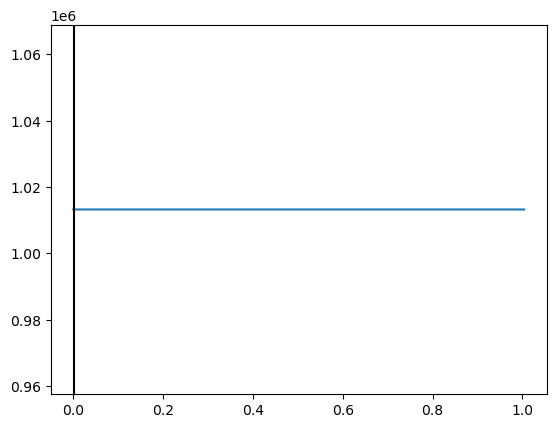

In [115]:
plt.plot(time, pressures)
plt.axvline(x=maxp_log, color='black')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim([0, 1e-2])

In [116]:
pressures

[1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 1013250.0,
 101

(0.0, 0.01)

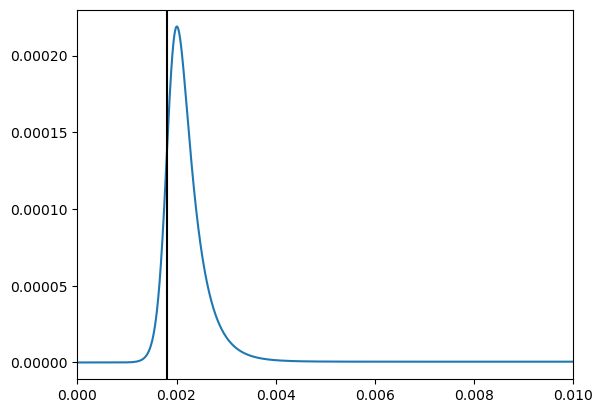

In [92]:
plt.plot(time, [a[OH_i] for a in core_species_concentrations])
plt.axvline(x=t_main, color='black')
# plt.xscale('log')
# plt.yscale('log')
plt.xlim([0, 1e-2])

(0.0015855361560947986,
 9.798042557375577e-05,
 0.0015855361560947986,
 0.0015855361560947986,
 True)

In [49]:
T = rmgpy.quantity.Quantity((830, 'K'))
P = rmgpy.quantity.Quantity((10, 'atm'))
termination_time = (1.0, 's')
termination = [rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity(termination_time))]
initial_mole_fractions = {
    species_list[fuel_i]: 0.03135,
    species_list[O2_i]: 0.2038,
    species_list[Ar_i]: 0.7649,
}

reaction_system = rmgpy.solver.simple.SimpleReactor(
    T=(800, 'K'),
    P=(10, 'atm'),
    initial_mole_fractions=initial_mole_fractions,
    termination=termination,
)


simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings()  # defaults
model_settings.tol_move_to_core = 0.1
model_settings.tol_interrupt_simulation = 1.0
model_settings.tol_keep_in_edge = 0.0


terminated, unkn, invalid_objects, surface_species, surface_reactions, t, conversion = reaction_system.simulate(
    core_species=species_list,
    core_reactions=reaction_list,
    edge_species=[],
    edge_reactions=[],
    surface_species=[],
    surface_reactions=[],
    model_settings=model_settings,
    simulator_settings=simulator_settings,
)


In [50]:
terminated

True

In [44]:
reaction_system

In [ ]:
ct.P

In [13]:
dir(ct)

['Arrhenius',
 'AxisymmetricStagnationFlow',
 'Boundary1D',
 'BurnerFlame',
 'CanteraError',
 'CarbonDioxide',
 'ChebyshevReaction',
 'ChemicallyActivatedReaction',
 'ConstPressureReactor',
 'ConstantCp',
 'CounterflowDiffusionFlame',
 'CounterflowPremixedFlame',
 'CounterflowTwinPremixedFlame',
 'Domain1D',
 'DustyGas',
 'DustyGasTransport',
 'Element',
 'ElementaryReaction',
 'Falloff',
 'FalloffReaction',
 'FlameBase',
 'FlowDevice',
 'FlowReactor',
 'FreeFlame',
 'FreeFlow',
 'Func1',
 'GasTransportData',
 'Heptane',
 'Hfc134a',
 'Hydrogen',
 'IdealGasConstPressureReactor',
 'IdealGasFlow',
 'IdealGasReactor',
 'ImpingingJet',
 'Inlet1D',
 'Interface',
 'InterfaceKinetics',
 'InterfacePhase',
 'InterfaceReaction',
 'IonBurnerFlame',
 'IonFlameBase',
 'IonFlow',
 'IonFreeFlame',
 'Kinetics',
 'MassFlowController',
 'Methane',
 'Mixture',
 'Mu0Poly',
 'Nasa9PolyMultiTempRegion',
 'NasaPoly2',
 'Nitrogen',
 'OrderedDict',
 'Outlet1D',
 'OutletReservoir1D',
 'Oxygen',
 'Path',
 'PlogRe

In [16]:
type(ct.Arrhenius())

cantera._cantera.Arrhenius

In [22]:
ct._cantera.__version__

'2.5.1'

In [ ]:
ct._cantera__version__